# 8.3 DLRM HSTU：长行为序列实战

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

如何把长期用户行为作为统一自回归序列训练，并让模型结构与大规模推荐系统共同设计？

## Setup

本 Notebook 的默认真实数据是 **KuaiRand feed 序列（smoke 教学适配器）；full 档使用 MovieLens 20M 公开基准**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。 **生成式章节默认要求 CUDA；无 CUDA 时只允许自动化测试执行 CPU basic smoke，不进行完整精度验证。**

**主要资料：** [Zhai et al., 2024, HSTU](https://arxiv.org/abs/2402.17152) · [Meta generative-recommenders](https://github.com/meta-recsys/generative-recommenders)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "movielens-20m"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'movielens-20m', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 如何把长期用户行为作为统一自回归序列训练，并让模型结构与大规模推荐系统共同设计？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

HSTU（Meta，2024）把推荐重新定义为序列转导任务：所有特征序列化成统一流，用 SiLU 逐点聚合注意力（不做整序列 softmax 归一化）加相对位置/时间偏置的单一块，替代 DLRM 的特征抽取、特征交互与表示变换三类拼装模块。本节默认在 CUDA 上用 Torch-RecHub HSTUModel 运行 next-item 训练；完整工业配置对齐 Meta DLRM-v3、TorchRec/FBGEMM 和 M-FALCON。

**来源：** [Zhai et al., 2024, HSTU](https://arxiv.org/abs/2402.17152) · [Meta generative-recommenders](https://github.com/meta-recsys/generative-recommenders)

### 原文实验设计与关键结论

原文 Table 4（公开数据，multi-pass full-shuffle 设定）：相对论文自跑的 SASRec，ML-1M HR@10 0.2853→0.3097（+8.6%，HSTU-large +15.5%），ML-20M +11.9%（large +22.8%），Books 0.0292→0.0404（+38.4%，large +60.6%），Books NDCG@10 最高 +65.8%。Table 5（工业单遍流式）消融显示换成 softmax 注意力或去掉相对偏置均退化；编码器与 FlashAttention-2 同配置对比，训练最高快 15.2 倍、推理快 5.6 倍（H100、bfloat16、序列 1024–8192）。Table 7（工业排序在线 A/B）：GR 相对 DLRM E-Task +12.4%、C-Task +4.4%；模型质量随训练算力幂律扩展，最大 1.5 万亿参数。以上是 Meta 系统口径，轻量实验只验证接口，数值不可相减。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** MovieLens 20M + Amazon Books  
**资源 ID：** `movielens-20m-full`  
**切分：** official generative-recommenders preprocessing  
**指标：** NDCG@10, HR@10  
**与论文比较边界：** use Meta public configs and identical sampled-softmax candidate count

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 3 · DLRM and HSTU components](/static/paper-figures/hstu.webp)

> **论文原图节选** · Figure 3 · DLRM and HSTU components · PDF p.4。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **逐点投影**：每个时间步的输入 $x_t$ 经一个线性层拆出门控 $U$、query $Q$、key $K$、value $V$ 四组向量。
- **Spatial Aggregation**：在因果范围内用 SiLU($QK^\top + rab^{p,t}$) 聚合 $V$，权重**不做 softmax 归一**，多个强相关历史可同时高贡献。
- **逐点变换 + 门控**：聚合结果与门控 $U(X)$ 逐元素相乘 $\operatorname{Norm}(A(X)V(X))\odot U(X)$，再过 $f_2$ 与残差连接进入下一层。

### 结构：一个模块替代 DLRM 的三类拼装件

DLRM 通常把特征抽取（embedding 查表）、特征交互（FM/DCN）、表示变换（MLP/MoE）拼成三段。HSTU 的主张是：把所有特征序列化成统一流 $X\in\mathbb R^{B\times L\times d}$：$B$ 个用户、每人最多 $L$ 个事件、每个事件 $d$ 维，然后反复堆叠同一种模块。论文 Eq.1/2/3 给出每个 HSTU 层的三个子层：

$$U,Q,K,V=\mathrm{Split}(\phi_1(f_1(X))),$$
$$A(X)V(X)=\phi_2\!\left(QK^\top+rab^{p,t}\right)V,$$
$$Y=f_2\!\left(\mathrm{Norm}(A(X)V(X))\odot U\right).$$

| 符号 | 含义 | 多头形状 |
|---|---|---|
| $f_1,f_2$ | 线性投影（论文为省算力各用一层） | 输入输出见上下文 |
| $\phi_1,\phi_2$ | 非线性激活，均取 SiLU | 不改变形状 |
| $Q,K$ | 每个位置提出的问题、供匹配的键；最后一维做点积 | $[B,L,H,d_q]$ |
| $V$ | 匹配后真正汇总的内容 | $[B,L,H,d_v]$ |
| $U$ | 与汇总结果逐元素相乘的门（类似 SwiGLU） | $[B,L,H,d_v]$ |
| $rab^{p,t}$ | 相对位置与时间偏置 | $[B,H,L,L]$（可广播） |
| $\mathrm{Norm}$ | 逐点聚合后稳定数值的 LayerNorm | 不改变形状 |
| $\odot$ | 逐元素相乘 | 两侧同形状 |

对每个 head，把 $q_{t,h}$ 与 $k_{j,h}$ 的 $d_q$ 个对应坐标相乘再求和，得到 $QK^\top\in\mathbb R^{B\times H\times L\times L}$；第 $(t,j)$ 格是位置 $t$ 对历史位置 $j$ 的内容相关分。它乘 $V$ 后回到 $[B,L,H,d_v]$，再与同形状的 $U$ 逐元素相乘、拼回 head 并经 $f_2$ 回到 $[B,L,d]$。

相对偏置可以读成“内容分之外的时间提示”。例如两次都看同一类别，内容点积一样；昨天发生的行为可获得比一年前行为更高的 $r_{\Delta p,\Delta t}$。它只依赖两个事件相隔多少位置、多少时间，不记绝对日期，所以同一条“刚看完就继续看”的规律能平移到任何一天。

### pointwise aggregated attention：不除总和的注意力

标准 softmax 注意力先把每行分数归一化成和为 1 再加权 $V$。HSTU 的 pointwise aggregated attention 直接对 $QK^\top+rab^{p,t}$ 施加 SiLU 后乘 $V$，不做整行归一化。

手算对比：设某位置对三条历史的相关分为 $(2,1,0.1)$。softmax 得 $(e^2,e^1,e^{0.1})/(e^2+e^1+e^{0.1})\approx(7.39,2.72,1.11)/11.22\approx(0.66,0.24,0.10)$——三条历史被迫瓜分固定为 1 的权重。SiLU$(z)=z\sigma(z)$ 则给出 $(2\times0.881,\ 1\times0.731,\ 0.1\times0.525)\approx(1.76,0.73,0.05)$：强相关历史的贡献不被“预算”压扁，“有几条相关历史”这个强度信号得以保留——论文指出这对预测观看时长这类强度目标至关重要。代价是数值不再自动有界，所以后面必须接 LayerNorm。SiLU 还有个顺手性质：负分数被压到接近 0（SiLU$(-4)\approx-0.07$），相当于软阈值。

### 因果约束、next-item 分数与交叉熵

$j\le t$ 的因果 mask 保证位置 $t$ 只能聚合不晚于 $t$ 的历史（$j>t$ 的格子被掩掉）。设位置 $t$ 的输出为 $h_t\in\mathbb R^d$，物品 $i$ 的输出 embedding 为 $e_i\in\mathbb R^d$，则下一物品分数和概率是

$$z_{t,i}=h_t^\top e_i+b_i,\qquad P(i\mid i_{\le t})=\frac{\exp z_{t,i}}{\sum_{j\in\mathcal V}\exp z_{t,j}},$$
$$L_{\text{next}}=-\sum_{t\ \text{有效}}\log P(i_{t+1}\mid i_{\le t}).$$

若某步正确物品概率从 0.2 提到 0.8，该步惩罚就从 $-\log0.2\approx1.609$ 降到 $-\log0.8\approx0.223$。一次前向会产生 logits `[B,L,|V|]`；padding 位置不计损失，推理只取最后有效位置的 `[B,|V|]` 做 Top-K。工业词表过大时可以使用 sampled-softmax，但候选采样必须写进协议；本教程小模型直接对教学词表做完整交叉熵。

HSTU 的论文级差异不在 next-item 目标，而在统一序列化特征、相对位置/时间偏置与不归一化的逐点聚合注意力。论文另配生成式训练采样（按 $1/n_i$ 采样用户把成本降一个 $O(N)$ 因子）与 M-FALCON 微批推理，属于工业配置，教学 Notebook 不展开。教程默认在 CUDA 上运行 Torch-RecHub 模型并启用混合精度；CPU basic smoke 只保留核心张量契约。

### 公式到代码

`run_hstu` 从 KuaiRand 真实 feed 流生成 next-item 样本并直接计算教学词表交叉熵；它不是 Meta full 数据/采样协议，实现映射会明确两者边界。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [序列与严格时间切分](/notebooks/3_2_data_ml_basics#split-leakage)
- [Q/K/V 张量形状](/notebooks/3_3_linear_algebra#low-rank-attention)
- [逐元素运算与 SiLU](/notebooks/3_4_calculus#functions)
- [序列负对数似然](/notebooks/3_6_information_theory#sequence-nll-dpo)

### 本论文新增数学（本节详细推导）

不经 softmax 的 Pointwise Aggregated Attention、相对位置/时间偏置，以及统一序列转导块。

给定 $[i_1,\ldots,i_t]$，模型在每个位置预测下一 item。因果 mask 保证位置 $t$ 只能看不晚于 $t$ 的历史。训练把所有位置交叉熵相加；推理只取最后位置 logits 做 Top-K。HSTU 把每行 softmax 归一化换成逐点 SiLU$(z)=z\sigma(z)$：各行不再共享总和为 1 的预算，多个强相关历史可以同时保持高贡献。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

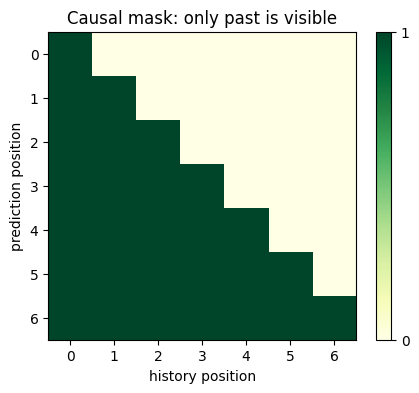

[[1 0 0 0 0 0 0]
 [1 1 0 0 0 0 0]
 [1 1 1 0 0 0 0]
 [1 1 1 1 0 0 0]
 [1 1 1 1 1 0 0]
 [1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1]]


In [2]:
import numpy as np, matplotlib.pyplot as plt
length=7; mask=np.tril(np.ones((length,length))); fig,ax=plt.subplots(figsize=(5,4)); image=ax.imshow(mask,cmap='YlGn',vmin=0,vmax=1)
ax.set(title='Causal mask: only past is visible',xlabel='history position',ylabel='prediction position')
ax.set_xticks(range(length)); ax.set_yticks(range(length)); plt.colorbar(image,ax=ax,ticks=[0,1]); plt.show(); print(mask.astype(int))

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** MovieLens 20M + Amazon Books  
**资源 ID：** `movielens-20m-full`  
**切分：** official generative-recommenders preprocessing  
**指标：** NDCG@10, HR@10  
**与论文比较边界：** use Meta public configs and identical sampled-softmax candidate count

### smoke 教学适配器（默认 runner 实际读取）

KuaiRand-Pure 的真实短视频点击流教学适配器：按毫秒时间排序，最后行为只作测试，训练只看更早的 next-video 转移。CUDA 只扩大该适配器规模；它不会自动切换到 Meta 的 MovieLens-20M + Amazon Books full 协议。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。无 CUDA 时的 CPU basic smoke 只验证基本功能，不产出精度结论。

## Model & Framework

实际使用 torch_rechub.models.generative.HSTUModel 完成 next-item 训练；工业档切换 Meta DLRM-v3、TorchRec/FBGEMM 和多 GPU。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。 本节默认使用 CUDA、混合精度与 TF32；没有 CUDA 时只运行缩小后的 CPU basic smoke，结果不进入完整精度结论。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.8_3_dlrm_hstu_practice.train")
run_hstu = chapter_train.run_hstu

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_hstu))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_hstu(
    epochs: int = 26,
    cpu_smoke: bool = False,
    *,
    progress: ProgressCallback | None = None,
) -> dict:
    # 1) 固定参数初始化，并读取本章指定的真实数据切片。
    emit_progress(progress, stage="data_prepare", current=0, total=1, message="加载数据并构造 HSTU 序列窗口")
    seed_everything(); device = _training_device(cpu_smoke)
    max_users, max_items, length = (32, 800, 8) if device.type == "cpu" else (128, 2500, 24)
    if full_profile():
        # 论文公开基准：MovieLens 20M 全部评分按时间序组成隐式序列。
        ratings, _, provenance = _real_hstu_dataset(max_users=max_users, max_items=max_items)
        interactions = ratings.assign(is_click=np.float32(1.0))
    else:
        interactions, _, provenance = _real_kuairand(max_users=max_users, max_items=max_items)
    sequences = clicked_sequences(interactions, min_length=length + 3)
    train_input, train_target, eval_input, eval_target = _sequence_windows_from_sequences(sequences, length)
    vocab = interactions.item_id.nunique() + 1
 

## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_hstu(cpu_smoke=not torch.cuda.is_available(), progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '最后位置 logits → Top-K 或 M-FALCON；服务需缓存状态、过滤非法/已见 item，并监控吞吐、显存和目录新鲜度。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载数据并构造 HSTU 序列窗口


[data_prepare] 1/1 sequence_users=29 vocab=801


[train] 0/2 分批训练 HSTU


[train] 1/2


[train] 2/2


...

[baseline] 0/1 计算热门物品基线


[baseline] 1/1 popularity_hr@5=0


[evaluate] 0/1 计算 HSTU HR@5


[evaluate] 1/1 hr@5=0


{'framework': 'torch_rechub.models.generative.HSTUModel', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '<ARTIFACT_ROOT>/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/kuairand-pure/standard_interactions.csv', 'rows_used': 7962, 'users_used': 32, 'items_used': 800, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:31:25+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'sequence_users': 29, 'sequence_length': 8, 'vocab': 801, 'strict_time_split': True}, 'device': 'cpu', 'validation_mode': 'cpu_basic_smoke'}
inference contra

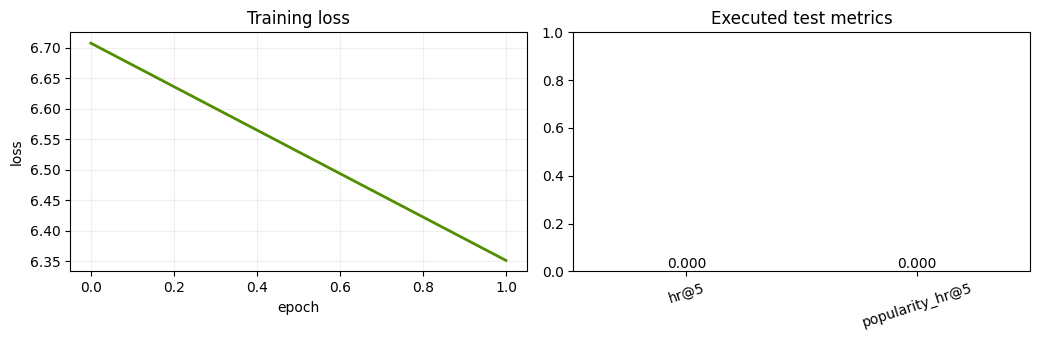

,value
hr@5,0.0
popularity_hr@5,0.0


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'hr@5': result['hr@5'], 'popularity_hr@5': result['popularity_hr@5']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "MovieLens 20M + Amazon Books", "resource": "movielens-20m-full", "split": "official generative-recommenders preprocessing", "metrics": ["NDCG@10", "HR@10"], "paper_comparison": "use Meta public configs and identical sampled-softmax candidate count"}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 hr@5 = **{result['hr@5']:.4f}**。
- 辅助指标 popularity_hr@5 = **{result['popularity_hr@5']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实小数据上的 HR 可能低于热门基线；这比可学习的人工序列更诚实，需通过严格时间切分、强 baseline 和成本收益共同判断。

### 工业边界

最后位置 logits → Top-K 或 M-FALCON；服务需缓存状态、过滤非法/已见 item，并监控吞吐、显存和目录新鲜度。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 hr@5 = **0.0000**。
- 辅助指标 popularity_hr@5 = **0.0000**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **6.7076** 降到 **6.3514**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实小数据上的 HR 可能低于热门基线；这比可学习的人工序列更诚实，需通过严格时间切分、强 baseline 和成本收益共同判断。

### 工业边界

最后位置 logits → Top-K 或 M-FALCON；服务需缓存状态、过滤非法/已见 item，并监控吞吐、显存和目录新鲜度。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'DLRM HSTU：长行为序列实战',
    'primary_metric': 'hr@5', 'primary_value': float(result['hr@5']),
    'secondary_metric': 'popularity_hr@5', 'secondary_value': float(result['popularity_hr@5']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '8_3_dlrm_hstu_practice',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_8','8_3_dlrm_hstu_practice',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_8/8_3_dlrm_hstu_practice.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['hr@5']) <= 1
assert np.isfinite(float(result['popularity_hr@5']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。